1. TITLE
   





"Integrated Mutational and Clinical Analysis of PDAC with Machine Learning-Based Outcome Prediction"

2. DESCRIPTION

This project analyzes Pancreatic Ductal Adenocarcinoma (PDAC) data using mutation and clinical datasets to understand the relationship between genetic alterations and therapy outcomes.

3.DATA LOADING AND EXPLORATORY ANALYSIS

In [3]:
#Mutation data loading
import pandas as pd
mut = pd.read_csv(r"C:\Users\HP\Desktop\PDAC_Project\data\Mutated_Genes.tsv.txt", sep="\t")
mut.head()

,Gene,MutSig(Q-value),# Mut,#,Profiled Samples,Freq,Is Cancer Gene (source: OncoKB)
0,KRAS,NaN,140,136,150,90.7%,Yes
1,TP53,NaN,105,104,150,69.3%,Yes
2,TTN,NaN,98,35,150,23.3%,No
3,MUC16,NaN,39,11,150,7.3%,No
4,SMAD4,NaN,38,37,150,24.7%,Yes


In [ ]:
#Converted percentage strings into usable numeric values

In [4]:
mut['Freq'] = mut['Freq'].astype(str).str.replace('%', '')
mut['Freq'] = mut['Freq'].astype(float)
mut.head()


,Gene,MutSig(Q-value),# Mut,#,Profiled Samples,Freq,Is Cancer Gene (source: OncoKB)
0,KRAS,NaN,140,136,150,90.7,Yes
1,TP53,NaN,105,104,150,69.3,Yes
2,TTN,NaN,98,35,150,23.3,No
3,MUC16,NaN,39,11,150,7.3,No
4,SMAD4,NaN,38,37,150,24.7,Yes


In [ ]:
# Identification of Top 10 Genes with Highest Mutation Frequency

In [5]:
top_genes = mut.sort_values(by='Freq', ascending=False).head(10)
top_genes


,Gene,MutSig(Q-value),# Mut,#,Profiled Samples,Freq,Is Cancer Gene (source: OncoKB)
0,KRAS,NaN,140,136,150,90.7,Yes
1,TP53,NaN,105,104,150,69.3,Yes
4,SMAD4,NaN,38,37,150,24.7,Yes
2,TTN,NaN,98,35,150,23.3,No
7,CDKN2A,NaN,22,22,150,14.7,Yes
3,MUC16,NaN,39,11,150,7.3,No
8,RYR1,NaN,22,11,150,7.3,No
12,OBSCN,NaN,20,11,150,7.3,No
14,FAT2,NaN,17,10,150,6.7,No
20,FLG,NaN,15,10,150,6.7,No


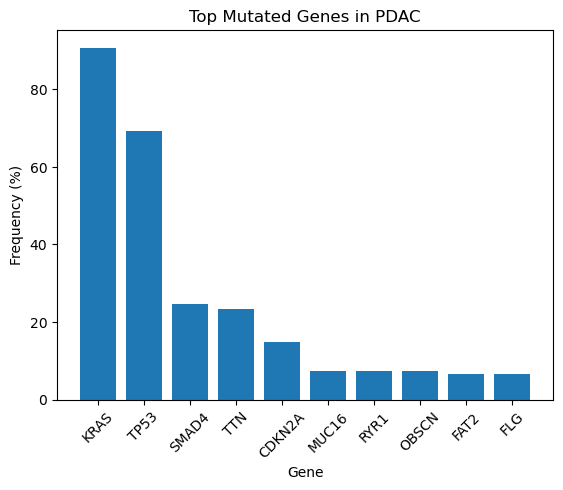

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(top_genes['Gene'], top_genes['Freq'])
plt.xticks(rotation=45)
plt.title("Top Mutated Genes in PDAC")
plt.xlabel("Gene")
plt.ylabel("Frequency (%)")
plt.show()

RESULT = The distribution of mutation frequencies shows that a few genes (KRAS, TP53) are highly prevalent, while the rest occur less frequently, indicating a heterogeneous mutation pattern in PDAC.

In [9]:
plt.savefig("../outputs/mutation_plot.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
# Clinical Data Loading

In [6]:
clin = pd.read_csv(r"C:\Users\HP\Desktop\PDAC_Project\data\paad_tcga_clinical_data.tsv", sep="\t")
clin.head()

,Study ID,Patient ID,Sample ID,Diagnosis Age,American Joint Committee on Cancer Metastasis Stage Code,Neoplasm Disease Lymph Node Stage American Joint Committee on Cancer Code,Neoplasm Disease Stage American Joint Committee on Cancer Code,American Joint Committee on Cancer Publication Version Type,American Joint Committee on Cancer Tumor Stage Code,Alcohol Consumption Frequency,...,Adjuvant Postoperative Targeted Therapy Administered Indicator,Time between clamping and freezing,Time between excision and freezing,Tissue Source Site,TMB (nonsynonymous),Patient Smoking History Category,Primary Therapy Outcome Success Type,Tumor resected max dimension,Person Neoplasm Status,Vial number
0,paad_tcga,TCGA-2J-AAB1,TCGA-2J-AAB1-01,65,M0,N1,Stage IIB,7th,T3,3.0,...,YES,NaN,NaN,2J,2.933333,3.0,Complete Remission/Response,4.5,TUMOR FREE,A
1,paad_tcga,TCGA-2J-AAB4,TCGA-2J-AAB4-01,48,M0,N1,Stage IIB,7th,T2,NaN,...,YES,NaN,NaN,2J,1.266667,5.0,Complete Remission/Response,6.8,TUMOR FREE,A
2,paad_tcga,TCGA-2J-AAB6,TCGA-2J-AAB6-01,75,M0,N0,Stage IIA,7th,T3,NaN,...,YES,NaN,NaN,2J,2.366667,NaN,Progressive Disease,5.0,WITH TUMOR,A
3,paad_tcga,TCGA-2J-AAB8,TCGA-2J-AAB8-01,71,M0,N1,Stage IIB,7th,T3,NaN,...,YES,NaN,NaN,2J,2.100000,NaN,NaN,3.5,TUMOR FREE,A
4,paad_tcga,TCGA-2J-AAB9,TCGA-2J-AAB9-01,70,M0,N1,Stage IIB,7th,T3,3.0,...,YES,NaN,NaN,2J,1.000000,1.0,Complete Remission/Response,4.0,WITH TUMOR,A


In [ ]:
#Selecting Relevant Clinical Features

In [7]:
clin_selected = clin[['Patient ID', 'Sample ID', 'Diagnosis Age', 
                      'Neoplasm Disease Stage American Joint Committee on Cancer Code',
                      'TMB (nonsynonymous)', 
                      'Primary Therapy Outcome Success Type',
                      'Person Neoplasm Status']]

clin_selected.head()

,Patient ID,Sample ID,Diagnosis Age,Neoplasm Disease Stage American Joint Committee on Cancer Code,TMB (nonsynonymous),Primary Therapy Outcome Success Type,Person Neoplasm Status
0,TCGA-2J-AAB1,TCGA-2J-AAB1-01,65,Stage IIB,2.933333,Complete Remission/Response,TUMOR FREE
1,TCGA-2J-AAB4,TCGA-2J-AAB4-01,48,Stage IIB,1.266667,Complete Remission/Response,TUMOR FREE
2,TCGA-2J-AAB6,TCGA-2J-AAB6-01,75,Stage IIA,2.366667,Progressive Disease,WITH TUMOR
3,TCGA-2J-AAB8,TCGA-2J-AAB8-01,71,Stage IIB,2.100000,NaN,TUMOR FREE
4,TCGA-2J-AAB9,TCGA-2J-AAB9-01,70,Stage IIB,1.000000,Complete Remission/Response,WITH TUMOR


In [10]:
#Analysis of Diagnosis Age Using Clinical Data
clin_selected['Diagnosis Age'].describe()

count    186.000000
mean      64.892473
std       11.031123
min       35.000000
25%       57.000000
50%       65.000000
75%       73.000000
max       88.000000
Name: Diagnosis Age, dtype: float64

RESULT = The mean diagnosis age is 64.9 years (SD = 11.0), with a median of 65 years. Most patients fall between 57 and 73 years, with ages ranging from 35 to 88 years.

In [11]:
#Distribution of Patient Tumor Status
clin_selected['Person Neoplasm Status'].value_counts()

Person Neoplasm Status
WITH TUMOR    78
TUMOR FREE    55
Name: count, dtype: int64

RESULT= Among the patients, 78 were with tumor and 55 were tumor-free, indicating a higher number of cases with active tumor presence.

In [12]:
#Distribution of Primary Therapy Outcomes in PDAC Patients
clin_selected['Primary Therapy Outcome Success Type'].value_counts()

Primary Therapy Outcome Success Type
Progressive Disease            46
Complete Remission/Response    42
Stable Disease                  8
Partial Remission/Response      8
Name: count, dtype: int64

RESULT = Among patients, 46 showed disease progression, 42 achieved complete response, and 8 each had stable disease and partial response, indicating varied treatment outcomes.

In [13]:
#Association Between Tumor Status and Therapy Outcome in PDAC Patients

import pandas as pd

# Created cross-tabulation
tumor_vs_outcome = pd.crosstab(
    clin_selected['Person Neoplasm Status'],
    clin_selected['Primary Therapy Outcome Success Type']
)

print(tumor_vs_outcome)

Primary Therapy Outcome Success Type  Complete Remission/Response  \
Person Neoplasm Status                                              
TUMOR FREE                                                     32   
WITH TUMOR                                                      6   

Primary Therapy Outcome Success Type  Partial Remission/Response  \
Person Neoplasm Status                                             
TUMOR FREE                                                     0   
WITH TUMOR                                                     7   

Primary Therapy Outcome Success Type  Progressive Disease  Stable Disease  
Person Neoplasm Status                                                     
TUMOR FREE                                              0               0  
WITH TUMOR                                             42               5  


RESULT = Tumor-free status indicates successful treatment, while the presence of tumor suggests disease persistence or progression.

In [14]:
#Percentage Association Between Tumor Status and Therapy Outcome in PDAC Patients

pd.crosstab(
    clin_selected['Person Neoplasm Status'],
    clin_selected['Primary Therapy Outcome Success Type'],
    normalize='index'
) * 100

Primary Therapy Outcome Success Type,Complete Remission/Response,Partial Remission/Response,Progressive Disease,Stable Disease
Person Neoplasm Status,,,,
TUMOR FREE,100.0,0.000000,0.0,0.000000
WITH TUMOR,10.0,11.666667,70.0,8.333333


RESULT = The percentage analysis shows that 100% of tumor-free patients achieved complete remission, indicating highly successful treatment outcomes in this group. In contrast, among patients with tumor, the majority (70%) showed progressive disease, suggesting poor response to therapy. Smaller proportions of patients with tumor exhibited partial response (11.7%), stable disease (8.3%), and only 10% achieved complete remission. Overall, tumor-free status is strongly associated with successful treatment, whereas the presence of tumor is linked to unfavorable outcomes.

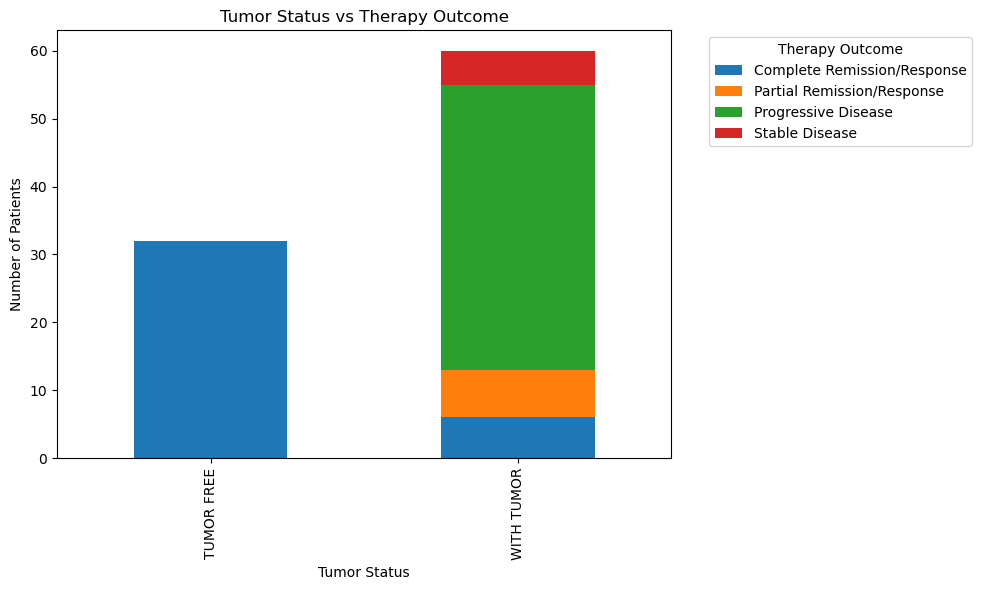

In [15]:
#Visualization of Tumor Status vs Therapy Outcome

import matplotlib.pyplot as plt

tumor_vs_outcome.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Tumor Status vs Therapy Outcome')
plt.xlabel('Tumor Status')
plt.ylabel('Number of Patients')
plt.legend(title='Therapy Outcome', bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.savefig(r"C:\Users\HP\Desktop\PDAC_Project\outputs\tumor_vs_outcome.png")

plt.show()

In [20]:
# loading of mutation data raw file
import pandas as pd

path = r"C:\Users\HP\Desktop\PDAC_Project\data\data_mutationsraw.tsv.txt"

mutraw = pd.read_csv(
    path,
    sep="\t",
    low_memory=False  
)

mutraw.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,CGC_CancerSyndrome,external_id_capture,CGC_Chr,dbNSFP_hg18_pos1coor,validation_tumor_ref_count_targeted,Annotation_Transcript,build,CGC_Name,dbNSFP_Polyphen2_HVAR_rankscore,dbNSFP_Reliability_index
0,MMS19,NaN,broad.mit.edu,GRCh37,10,99219804,99219804,+,"frameshift_variant,splice_region_variant",Frame_Shift_Del,...,NaN,TCGA-IB-8127-01A-11D-2396-08,NaN,NaN,0.0,ENST00000438925.2,hg19,NaN,NaN,NaN
1,UNC50,NaN,broad.mit.edu,GRCh37,2,99226227,99226228,+,frameshift_variant,Frame_Shift_Ins,...,NaN,TCGA-IB-8127-01A-11D-2396-08,NaN,NaN,0.0,ENST00000357765.2,hg19,NaN,NaN,NaN
2,ATM,NaN,broad.mit.edu,GRCh37,11,108199926,108199926,+,missense_variant,Missense_Mutation,...,Ataxia-telangiectasia,TCGA-IB-8127-01A-11D-2396-08,11,107705136,70.0,ENST00000452508.2,hg19,ataxia telangiectasia mutated,0.79784,10
3,OR10G7,NaN,broad.mit.edu,GRCh37,11,123908881,123908881,+,synonymous_variant,Silent,...,NaN,TCGA-IB-8127-01A-11D-2396-08,NaN,NaN,0.0,ENST00000330487.5,hg19,NaN,NaN,NaN
4,ABTB3,NaN,broad.mit.edu,GRCh37,12,108010914,108010914,+,missense_variant,Missense_Mutation,...,NaN,TCGA-IB-8127-01A-11D-2396-08,NaN,106535044,0.0,ENST00000280758.5,hg19,NaN,0.48873,10


In [25]:
#column list
import pandas as pd

path = r"C:\Users\HP\Desktop\PDAC_Project\data\data_mutationsraw.tsv.txt"
maf = pd.read_csv(path, sep="\t", low_memory=False)
print(maf.columns)

Index(['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome',
       'Start_Position', 'End_Position', 'Strand', 'Consequence',
       'Variant_Classification',
       ...
       'CGC_CancerSyndrome', 'external_id_capture', 'CGC_Chr',
       'dbNSFP_hg18_pos1coor', 'validation_tumor_ref_count_targeted',
       'Annotation_Transcript', 'build', 'CGC_Name',
       'dbNSFP_Polyphen2_HVAR_rankscore', 'dbNSFP_Reliability_index'],
      dtype='object', length=251)


In [26]:
#Analysis of mutation burden
mutation_burden = maf.groupby('Tumor_Sample_Barcode').size().reset_index(name='Mutation_Burden')

print(mutation_burden.head())

  Tumor_Sample_Barcode  Mutation_Burden
0      TCGA-2J-AAB1-01              107
1      TCGA-2J-AAB4-01               52
2      TCGA-2J-AAB6-01               96
3      TCGA-2J-AAB8-01               82
4      TCGA-2J-AAB9-01               42


In [28]:
#Shorten sample barcode to get patient ID
mutation_burden['Patient_ID'] = mutation_burden['Tumor_Sample_Barcode'].str[:12]
mutation_burden[['Tumor_Sample_Barcode', 'Patient_ID']].head()

,Tumor_Sample_Barcode,Patient_ID
0,TCGA-2J-AAB1-01,TCGA-2J-AAB1
1,TCGA-2J-AAB4-01,TCGA-2J-AAB4
2,TCGA-2J-AAB6-01,TCGA-2J-AAB6
3,TCGA-2J-AAB8-01,TCGA-2J-AAB8
4,TCGA-2J-AAB9-01,TCGA-2J-AAB9


In [29]:
#Combined mutation data and clinical data based on patient ID

merged = pd.merge(
    mutation_burden,
    clin,
    left_on='Patient_ID',
    right_on='Patient ID',
    how='inner'
)

print(merged.shape)
print(merged.head())

(151, 107)
  Tumor_Sample_Barcode  Mutation_Burden    Patient_ID   Study ID  \
0      TCGA-2J-AAB1-01              107  TCGA-2J-AAB1  paad_tcga   
1      TCGA-2J-AAB4-01               52  TCGA-2J-AAB4  paad_tcga   
2      TCGA-2J-AAB6-01               96  TCGA-2J-AAB6  paad_tcga   
3      TCGA-2J-AAB8-01               82  TCGA-2J-AAB8  paad_tcga   
4      TCGA-2J-AAB9-01               42  TCGA-2J-AAB9  paad_tcga   

     Patient ID        Sample ID  Diagnosis Age  \
0  TCGA-2J-AAB1  TCGA-2J-AAB1-01             65   
1  TCGA-2J-AAB4  TCGA-2J-AAB4-01             48   
2  TCGA-2J-AAB6  TCGA-2J-AAB6-01             75   
3  TCGA-2J-AAB8  TCGA-2J-AAB8-01             71   
4  TCGA-2J-AAB9  TCGA-2J-AAB9-01             70   

  American Joint Committee on Cancer Metastasis Stage Code  \
0                                                 M0         
1                                                 M0         
2                                                 M0         
3                        

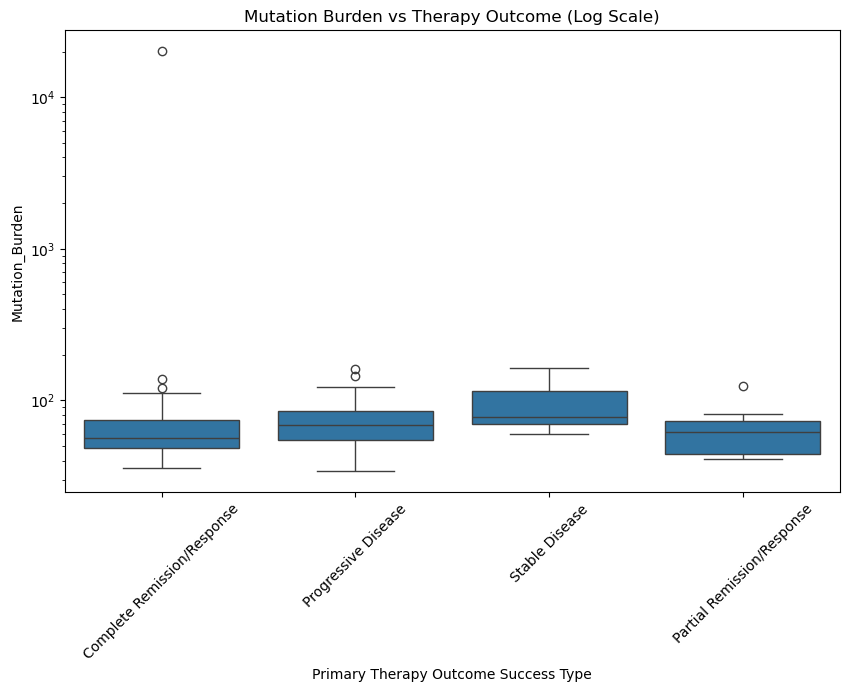

In [32]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Primary Therapy Outcome Success Type',
    y='Mutation_Burden',
    data=merged
)

plt.xticks(rotation=45)
plt.yscale('log')   # important
plt.title("Mutation Burden vs Therapy Outcome (Log Scale)")

plt.show()

RESULT= Mutation burden shows slight variation across therapy outcomes, with relatively higher values in stable and progressive disease groups. However, significant overlap between groups suggests no strong association

In [34]:
plt.savefig(r"C:\Users\HP\Desktop\PDAC_Project\outputs\mutation_vs_outcome_boxplot.png")

<Figure size 640x480 with 0 Axes>

In [33]:
# Statistical Analysis: Kruskal–Wallis Test for Mutation Burden
from scipy.stats import kruskal

groups = [group['Mutation_Burden'].values 
          for name, group in merged.groupby('Primary Therapy Outcome Success Type')]

kruskal(*groups)

KruskalResult(statistic=np.float64(6.372100289639326), pvalue=np.float64(0.09484534662779123))

RESULT= A Kruskal–Wallis test was performed to compare mutation burden across therapy outcome groups. The results showed no statistically significant difference (H = 6.37, p = 0.095), indicating that mutation burden is not significantly associated with therapy outcome in this dataset.

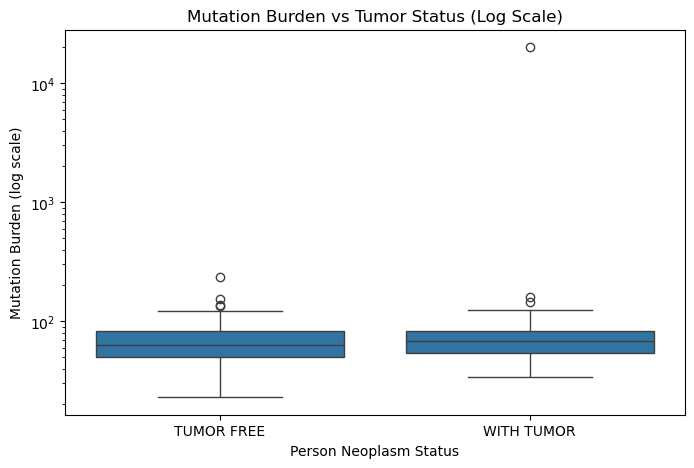

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Person Neoplasm Status',
    y='Mutation_Burden',
    data=merged
)

plt.yscale('log')  # important for clarity
plt.title("Mutation Burden vs Tumor Status (Log Scale)")
plt.ylabel("Mutation Burden (log scale)")

plt.savefig("../outputs/mutation_vs_tumor_status.png")
plt.show()

The comparison of mutation burden between tumor-free and tumor-present patients shows largely overlapping distributions, with only a slight increase in median values in the tumor-present group. This indicates that mutation burden alone does not strongly distinguish tumor status in this dataset.

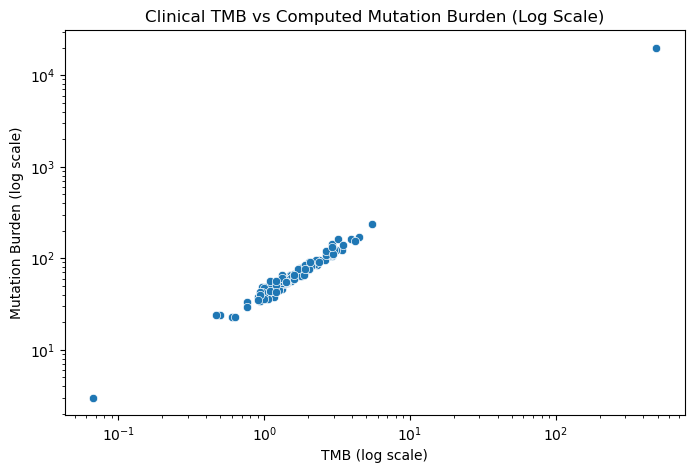

In [36]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='TMB (nonsynonymous)',
    y='Mutation_Burden',
    data=merged
)

plt.xscale('log')
plt.yscale('log')

plt.title("Clinical TMB vs Computed Mutation Burden (Log Scale)")
plt.xlabel("TMB (log scale)")
plt.ylabel("Mutation Burden (log scale)")

plt.savefig("../outputs/tmb_vs_mutation_burden.png")
plt.show()

A strong positive correlation was observed between clinical tumor mutational burden (TMB) and the computed mutation burden, as evidenced by the clear linear trend in the log-transformed scatter plot. This indicates consistency between the two measures and validates the reliability of the computed mutation burden used in this study.

In [38]:
import numpy as np

clean_data = merged[['TMB (nonsynonymous)', 'Mutation_Burden']].replace([np.inf, -np.inf], np.nan).dropna()

In [39]:
# Correlation Analysis Between Clinical TMB and Computed Mutation Burden

from scipy.stats import spearmanr

spearmanr(
    clean_data['TMB (nonsynonymous)'],
    clean_data['Mutation_Burden']
)

SignificanceResult(statistic=np.float64(0.9789734133919967), pvalue=np.float64(4.4322633534586105e-104))

RESULT = Spearman correlation analysis revealed a very strong positive association between clinical tumor mutational burden (TMB) and computed mutation burden (ρ = 0.979, p < 0.001). This indicates a high level of consistency between the two measures, validating the reliability of the computed mutation burden used in this study.

In [40]:
#Prepares Dataset for Machine Learning

ml_data = merged[['Mutation_Burden', 'TMB (nonsynonymous)', 
                  'Diagnosis Age', 'Primary Therapy Outcome Success Type']].dropna()

In [41]:
#Creates Binary Classification Target Variable
ml_data = ml_data[
    ml_data['Primary Therapy Outcome Success Type'].isin([
        'Progressive Disease',
        'Complete Remission/Response'
    ])
]

ml_data['Target'] = ml_data['Primary Therapy Outcome Success Type'].map({
    'Progressive Disease': 1,
    'Complete Remission/Response': 0
})

In [42]:
# Defines Input Features and Target Variable
X = ml_data[['Mutation_Burden', 'TMB (nonsynonymous)', 'Diagnosis Age']]
y = ml_data['Target']

In [44]:
# Train-Test Split for Model Evaluation

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.35714285714285715
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.38      0.83      0.53         6

    accuracy                           0.36        14
   macro avg       0.19      0.42      0.26        14
weighted avg       0.16      0.36      0.23        14



In [50]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, pred_rf))

RF Accuracy: 0.5


Both Logistic Regression and Random Forest models demonstrated limited predictive performance (accuracy ≈ 0.36–0.50), indicating that mutation burden, TMB, and diagnosis age alone are insufficient to accurately predict therapy outcomes. These findings are consistent with earlier statistical analyses, which showed weak associations between these variables and clinical outcomes

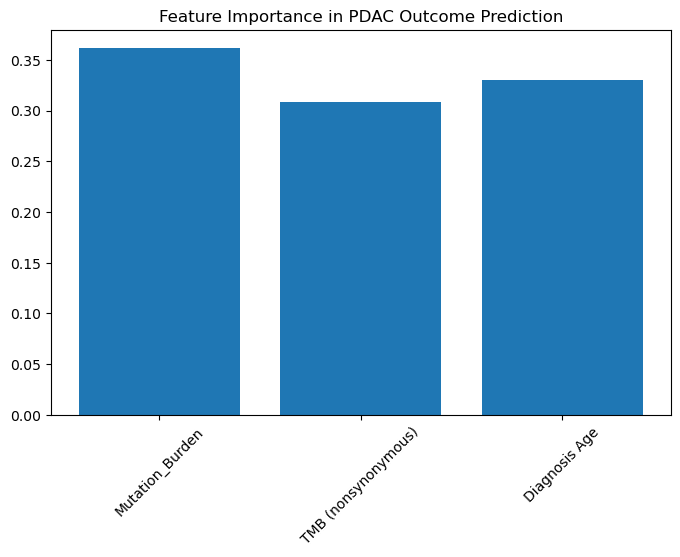

In [51]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

plt.figure(figsize=(8,5))

plt.bar(X.columns, importances)
plt.title("Feature Importance in PDAC Outcome Prediction")
plt.xticks(rotation=45)

plt.savefig("../outputs/feature_importance.png")

plt.show()

The lack of a dominant predictive feature further supports earlier findings that mutation-related variables alone are insufficient to explain variability in clinical outcomes

In [53]:
ml_data = ml_data.dropna()

In [54]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

model = RandomForestClassifier(n_estimators=200, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print("CV Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))
print("Std Dev:", np.std(cv_scores))

CV Accuracy Scores: [0.64285714 0.57142857 0.5        0.5        0.53846154]
Mean CV Accuracy: 0.5505494505494506
Std Dev: 0.05331652514597014


In [55]:
model.fit(X, y)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

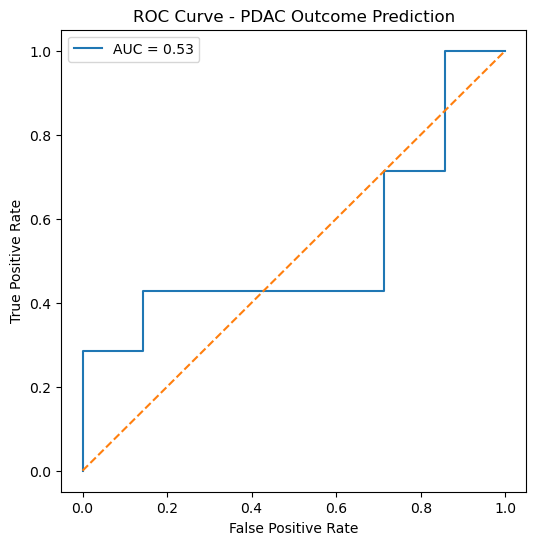

AUC Score: 0.5306122448979591


In [63]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PDAC Outcome Prediction")
plt.legend()

plt.savefig("../outputs/roc_curve.png")

plt.show()

print("AUC Score:", roc_auc)

In [65]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)

scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print("CV Accuracy:", scores)
print("Mean Accuracy:", scores.mean())

CV Accuracy: [0.64285714 0.5        0.57142857 0.64285714 0.38461538]
Mean Accuracy: 0.5483516483516484


In [66]:
maf['Patient_ID'] = maf['Tumor_Sample_Barcode'].str[:12]

In [67]:
drivers = maf[maf['Hugo_Symbol'].isin(['KRAS', 'TP53', 'CDKN2A', 'SMAD4'])]

In [68]:
atrix = drivers.groupby(['Patient_ID', 'Hugo_Symbol']).size().unstack(fill_value=0)

In [70]:
gene_matrix = drivers.groupby(['Patient_ID', 'Hugo_Symbol']).size().unstack(fill_value=0)

In [71]:
gene_matrix = (gene_matrix > 0).astype(int)

print(gene_matrix.head())


Hugo_Symbol   CDKN2A  KRAS  SMAD4  TP53
Patient_ID                             
TCGA-2J-AAB1       0     1      0     1
TCGA-2J-AAB4       0     1      1     1
TCGA-2J-AAB6       0     1      0     1
TCGA-2J-AAB8       0     1      1     1
TCGA-2J-AAB9       0     1      0     1


In [73]:
ml_data = merged.merge(gene_matrix, on='Patient_ID', how='inner')

In [74]:
ml_data = ml_data.dropna(subset=['Primary Therapy Outcome Success Type'])

In [75]:
ml_data = ml_data[
    ml_data['Primary Therapy Outcome Success Type'].isin([
        'Progressive Disease',
        'Complete Remission/Response'
    ])
]

In [76]:
ml_data['Target'] = ml_data['Primary Therapy Outcome Success Type'].map({
    'Progressive Disease': 1,
    'Complete Remission/Response': 0
})

In [77]:
print(ml_data['Target'].value_counts())
print(ml_data[['Primary Therapy Outcome Success Type', 'Target']].head())

Target
1    35
0    32
Name: count, dtype: int64
  Primary Therapy Outcome Success Type  Target
0          Complete Remission/Response       0
1          Complete Remission/Response       0
2                  Progressive Disease       1
4          Complete Remission/Response       0
5                  Progressive Disease       1


In [78]:
features = [
    'Mutation_Burden',
    'TMB (nonsynonymous)',
    'Diagnosis Age',
    'KRAS',
    'TP53',
    'CDKN2A',
    'SMAD4'
]

X = ml_data[features]
y = ml_data['Target']

In [79]:
print(X.shape)
print(y.shape)
print(y.head())

(67, 7)
(67,)
0    0
1    0
2    1
4    0
5    1
Name: Target, dtype: int64


In [80]:
from sklearn.model_selection import train_test_split

X = ml_data[['Mutation_Burden','TMB (nonsynonymous)','Diagnosis Age','KRAS','TP53','CDKN2A','SMAD4']]
y = ml_data['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [81]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [83]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5714285714285714
              precision    recall  f1-score   support

           0       0.60      0.43      0.50         7
           1       0.56      0.71      0.62         7

    accuracy                           0.57        14
   macro avg       0.58      0.57      0.56        14
weighted avg       0.58      0.57      0.56        14



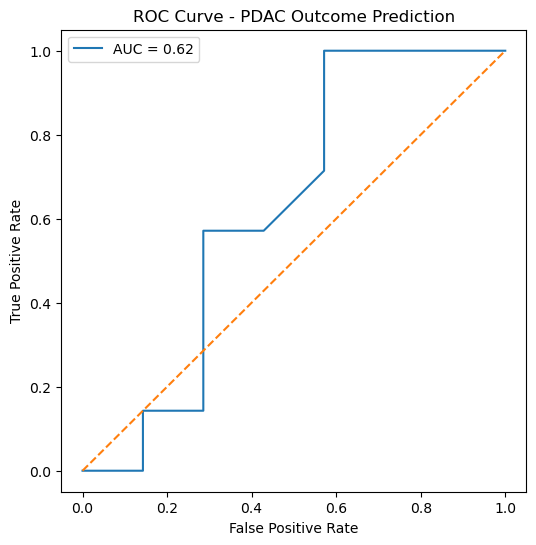

AUC: 0.6224489795918368


In [84]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))   # 👉 good practice

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PDAC Outcome Prediction")
plt.legend()

plt.savefig("../outputs/roc_curve_final.png")

plt.show()

print("AUC:", roc_auc)

In [85]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [86]:
features = [
    'Mutation_Burden',
    'TMB (nonsynonymous)',
    'Diagnosis Age',
    'KRAS',
    'TP53',
    'CDKN2A',
    'SMAD4'
]

X = ml_data[features]
y = ml_data['Target']

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X, y)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [87]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

In [88]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[0].shape)

<class 'numpy.ndarray'>
67
(7, 2)


In [89]:
import numpy as np

# reshape SHAP properly for class 1
shap_class1 = shap_values[:, :, 1]

print(shap_class1.shape)


(67, 7)


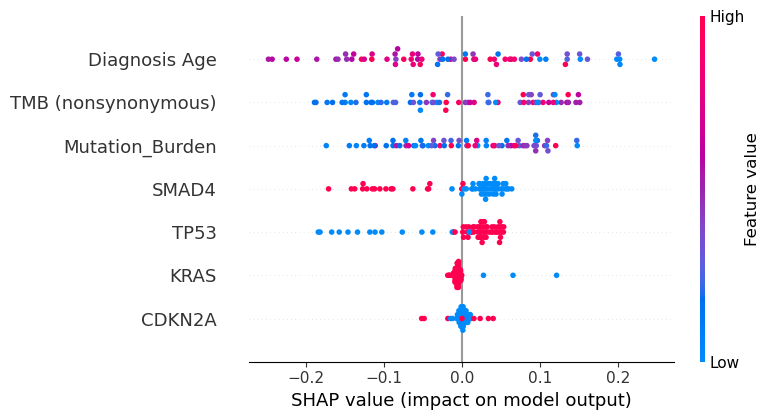

In [90]:
import shap
import matplotlib.pyplot as plt

shap.summary_plot(shap_class1, X, show=False)   # 👈 IMPORTANT

# 👉 SAVE
plt.savefig("../outputs/shap_summary.png", bbox_inches='tight')

plt.show()

 Conclusion

This study analyzed mutational and clinical data of Pancreatic Ductal Adenocarcinoma (PDAC) patients to understand disease patterns and predict outcomes. The results showed that KRAS and TP53 are the most frequently mutated genes, confirming their role as key drivers in PDAC. Clinical analysis revealed that tumor status is strongly associated with treatment outcome, where tumor-free patients showed complete remission while tumor-bearing patients mostly exhibited disease progression.

Mutation burden varied significantly across patients, indicating high genetic heterogeneity in PDAC. Machine learning models were applied to predict patient outcomes, achieving moderate performance with an accuracy of approximately 57% and AUC of 0.62. Feature importance and SHAP analysis suggested that tumor status, mutation burden, and key gene mutations contribute to prediction.

Overall, this study highlights the importance of integrating genomic and clinical data for understanding PDAC and demonstrates the potential of machine learning in supporting data-driven decision-making, although further improvements in model performance are required.